Agentic Data Analyst 

In [14]:
from typing import TypedDict, Any, Literal
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

In [15]:
class AgentState(TypedDict):
    user_response: str
    doc_info: str 
    rag_route: str
    schema_info: str
    sql: str
    sql_valid: bool
    final_answer: str
    chart_needed: str
    chart_specs: dict[str, Any]
    chart: object

In [16]:
class ChartSpecs(BaseModel):
    chart_type: Literal["scatter","line","bar","pie"]
    x: str
    y: str
    title: str

In [17]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b", api_key=os.getenv("GROQ_API_KEY"))

In [18]:
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv()

connection = psycopg2.connect(
    host="localhost",
    port=5432,
    dbname="Adventureworks",
    user="postgres",
    password=os.getenv("DB_PASSWORD")
)

print("Connection successful!")

Connection successful!


In [19]:
def retrieve_doc_info(state:AgentState) -> AgentState:
    """This node retrieves information from internal AdevntureWorks documentation"""
    #testing
    state["doc_info"] = "Net line revenue is calculated as the unit price * (1 - unit price discount) * order quantity for each product"
    SYSTEM_PROMT = f'''
                    Determine whether the user's question requires querying the database to answer.
                        User question: {state["user_response"]}
                        Business context: {state["doc_info"]}

                    Return exactly one:
                        END: The question can sufficiently be answered using the business context. 
                        SCHEMA: The question reqiures database information.
                '''

    state["rag_route"] = llm.invoke(SYSTEM_PROMT).content.strip()
    if state["rag_route"] == "END":
            state["final_answer"] = state["doc_info"]
    
    return state

In [20]:
def get_relavent_schema(state:AgentState) -> AgentState:
    """This node gets the relavent tables and columns needed to peform the analysis or calculation"""
    #testing
    state["schema_info"] = "sales.salesorderdetail.unitprice, sales.salesorderdetail.unitpricediscount, sales.salesorderdetail.orderqty,  sales.salesorderdetail.productid"
    return state

In [21]:
import re

def clean_sql(sql: str) -> str:
    sql = sql.strip()

    # Remove ```sql ... ``` or ``` ... ```
    sql = re.sub(r"^```(?:sql)?\s*", "", sql, flags=re.IGNORECASE)
    sql = re.sub(r"\s*```$", "", sql)

    return sql.strip()

def generate_sql(state:AgentState) -> AgentState:
    """This node generates the appropriate SQL"""
    #testing
    SYSTEM_PROMPT=f'''
        Generate SQL provided these parameters. Purely SQL only:
            user question: {state["user_response"]},
            documentation: {state["doc_info"]},
            schema info: {state["schema_info"]}
    '''
    generated_sql = llm.invoke(SYSTEM_PROMPT).content
    state["sql"] = clean_sql(generated_sql)
    return state

    

In [22]:
import sqlglot
from sqlglot import exp

# uses sqlglot library which parses the sql to check if the syntax is correct 
def check_sql_syntax(sql:str) -> bool:
    try:
        sqlglot.parse_one(sql,dialect="postgres")
        return True
    except sqlglot.errors.ParseError:
        return False

# uses exp from sqlglot to check if the query is a SELECT or WITH query (read-only) - for safety 
def check_read_only(sql:str) -> bool:
    try:
        parsed = sqlglot.parse_one(sql, dialect="postgres")

        #Allow SELECT queries
        if isinstance(parsed, exp.Select):
            return True

        #Allow WITH... SELECT queries
        if isinstance(parsed, exp.With):
            return True

        return False

    except sqlglot.errors.ParseError:
        return False

def validate_sql(state: AgentState) -> AgentState:
    """This node validates the SQL that was generated by the LLM"""

    #testing
    syntax_valid = check_sql_syntax(state["sql"])
    read_only = check_read_only(state["sql"])

    if not syntax_valid: 
        state["sql_valid"] = False

    if not read_only:
        state["sql_valid"] = False

    SYSTEM_PROMPT = f'''
                        Determine whether this SQL correctly answers the user's question.

                        User question: {state["user_response"]}
                        Business context: {state["doc_info"]}
                        Database schema: {state["schema_info"]}
                        Generated SQL: {state["sql"]}

                        Check:
                            1. Does it answer the question?
                            2. Does it use the correct tables and columns?
                            3. Does it follow the business definitions?
                            4. Are the calculations correct?

                        Return only: VALID or INVALID
                    '''
    response = llm.invoke(SYSTEM_PROMPT).content.strip()

    if response == "VALID":
        state["sql_valid"] = True
    else:
        state["sql_valid"] = False

    return state

In [23]:
def execute_sql(state:AgentState)->AgentState:
    """This node executes the SQL generated"""
    cursor = connection.cursor()

    query = state["sql"]
    cursor.execute(query)
    result = cursor.fetchall()
    cursor.close()
    state["final_answer"] = result     

    return state

In [24]:
def analyze_result(state:AgentState) -> AgentState:
    """This node analyzes the result and determines if a chart is needed or not"""

    SYSTEM_PROMPT1 = f'''
                    You are analyzing the result of a database query.
        
                    User Question: {state["user_response"]}
                    Query Result: {state["final_answer"]}
        
                    Determine whether a chart would meaningfully improve the answer.
        
                    Return exactly: REDO or CHART or NO_CHART
        
                    Use REDO when the result:
                    - is resulting in errors 
                    - not answering the user's question

                    Use CHART when the result show:
                    - a trend over time
                    - comparison between categories 
                    - rankings
                    - proportions
                    - relationships between numeric variables 
        
                    Use NO_CHART when: 
                    - the result is a single value
                    - the result is mainly explanatory text
                    - a chart would not add meaningful insight 
            ''' 
    
    state["chart_needed"] = llm.invoke(SYSTEM_PROMPT1).content.strip()     

    structured_llm = llm.with_structured_output(ChartSpecs)

    if state["chart_needed"] == "CHART":
        SYSTEM_PROMPT2 = f'''
            You must determine the appropirate specifications for a chart provided the following query result.

            Qeury Result: {state["final_answer"]}

                - choose the appropriate chart type
                - choose the x and y columns
                - provide a clear title
        '''
        state["chart_specs"] = structured_llm.invoke(SYSTEM_PROMPT2)

    return state
    

In [25]:
import plotly.express as px

def create_chart(state:AgentState) -> AgentState:
    results = state["final_answer"]
    specs = state["chart_specs"]
    chart_type = specs.chart_type
    x = specs.x
    y = specs.y
    title = specs.title

    if x not in results[0] or y not in results[0]:
        raise ValueError("Chart columns not found in query results")

    if chart_type == "bar":
        fig = px.bar(results, x=x, y=y, title=title)

    elif chart_type == "line":
        fig = px.line(results, x=x, y=y, title=title)

    elif chart_type == "pie":
        fig = px.pie(results, names=x, values=y, title=title)

    elif chart_type == "scatter":
        fig = px.scatter(results, x=x, y=y, title=title)

    else:
        raise ValueError(f"Unsupported chart type: {chart_type}")

    state["chart"] = fig

    return state


In [26]:
graph = StateGraph(AgentState)

graph.add_node("rag", retrieve_doc_info)
graph.add_node("schema", get_relavent_schema)
graph.add_node("sql", generate_sql)
graph.add_node("validate", validate_sql)
graph.add_node("execute", execute_sql)
graph.add_node("analyze", analyze_result)
graph.add_node("chart", create_chart)


graph.add_edge(START, "rag")

graph.add_conditional_edges("rag", 
                                lambda state: state["rag_route"],
                                {
                                    "END": END,
                                    "SCHEMA": "schema"
                                }
                            )
# graph.add_edge("rag", "schema")
graph.add_edge("schema", "sql")
graph.add_edge("sql", "validate")
graph.add_conditional_edges("validate", 
                                lambda state: state["sql_valid"],
                                {
                                    True: "execute",
                                    False: "sql"
                                }
                            )
graph.add_edge("execute", "analyze")
graph.add_conditional_edges("analyze",
                            lambda state: state["chart_needed"],
                            {
                                "REDO": "sql",
                                "CHART": "chart",
                                "NO_CHART": END
                            })
graph.add_edge("chart", END)
app = graph.compile()

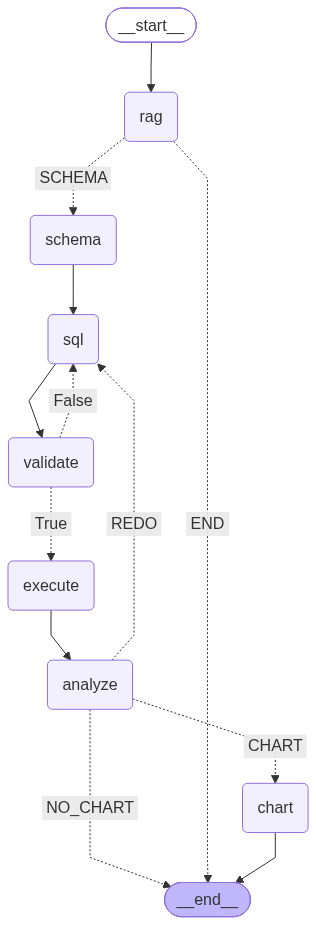

In [27]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
state_initial=AgentState(user_response="What is the total net revenue?")
print(app.invoke(state_initial))

{'user_response': 'What is the total net revenue?', 'doc_info': 'Net line revenue is calculated as the unit price * (1 - unit price discount) * order quantity for each product', 'rag_route': 'SCHEMA', 'schema_info': 'sales.salesorderdetail.unitprice, sales.salesorderdetail.unitpricediscount, sales.salesorderdetail.orderqty,  sales.salesorderdetail.productid', 'sql': 'SELECT SUM(unitprice * (1 - unitpricediscount) * orderqty) AS total_net_revenue\nFROM sales.salesorderdetail;', 'sql_valid': True, 'final_answer': [(Decimal('109846381.39988800'),)], 'chart_needed': 'NO_CHART'}
